In [1]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
from astropy.cosmology import FlatLambdaCDM
from astropy.io import fits

from mock_config import CONFIG, BGS_CLUS

cosmo = FlatLambdaCDM(H0=100., Om0=0.31)

In [8]:
print(CONFIG.data_bgs_clus_data)
print(CONFIG.data_bgs_clus_rand)

/global/cfs/cdirs/desi/science/td/pv/bgsclustering/Y3/BGS_BRIGHT_clustering_forPV_data.fits
/global/cfs/cdirs/desi/science/td/pv/bgsclustering/Y3/BGS_BRIGHT_clustering_forPV_random.fits


In [55]:
d0_data = fits.open(CONFIG.data_bgs_clus_data.replace('data.fits', 'data_nolumcut.fits'))[1].data
d0_rand = fits.open(CONFIG.data_bgs_clus_rand.replace('random.fits', 'random_nolumcut.fits'))[1].data
print(d0_data.names, d0_rand.names, d0_data.size, d0_rand.size)

['RA', 'DEC', 'Z', 'WEIGHT', 'ABSMAG01_SDSS_R'] ['RA', 'DEC', 'Z', 'WEIGHT'] 1135795 80333294


In [10]:
m0_data = h5py.File(CONFIG.mock_bgs_base_data.format(phase=0, real=0), 'r')
m0_rand = h5py.File(CONFIG.mock_bgs_base_rand.format(phase=0, real=0), 'r')
print(list(m0_data.keys()))
print(list(m0_rand.keys()))

['Y1_COMP', 'Y3_COMP', 'Y5', 'abs_mag', 'app_mag', 'col', 'col_obs', 'dec', 'halo_ind', 'halo_mass', 'is_cen', 'is_res', 'ra', 'vel', 'zcos', 'zobs']
['Y1_COMP', 'Y3_COMP', 'Y5', 'abs_mag', 'app_mag', 'col', 'col_obs', 'dec', 'halo_mass', 'ra', 'zcos', 'zobs']


In [46]:
m0_app_mag = m0_data['app_mag'][...]
m0_zobs = m0_data['zobs'][...]
m0_abs_mag = m0_data['abs_mag'][...]

mask = (m0_app_mag < BGS_CLUS.appmaglim) & (m0_abs_mag < BGS_CLUS.absmaglim) 


Text(0.5, 0, 'Apparent r-band magnitude')

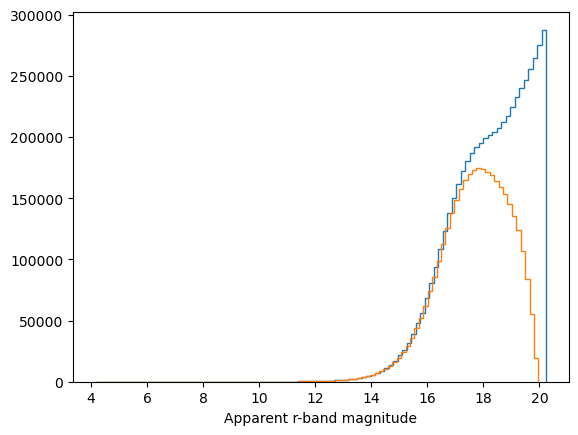

In [47]:
plt.hist(m0_app_mag, bins=100, histtype='step')
plt.hist(m0_app_mag[mask], bins=100, histtype='step')
plt.xlabel('Apparent r-band magnitude')

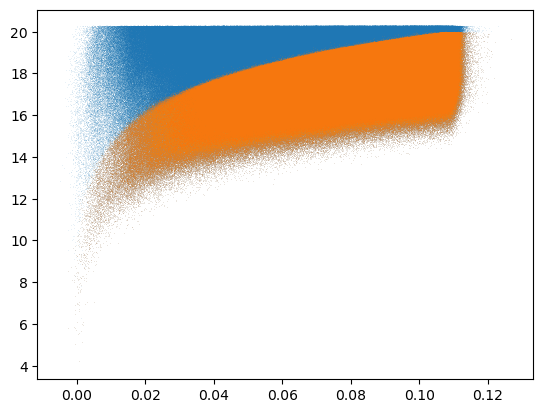

In [48]:

plt.plot(m0_zobs, m0_app_mag, ',', alpha=0.1)
plt.plot(m0_zobs[mask], m0_app_mag[mask], ',', alpha=0.1)


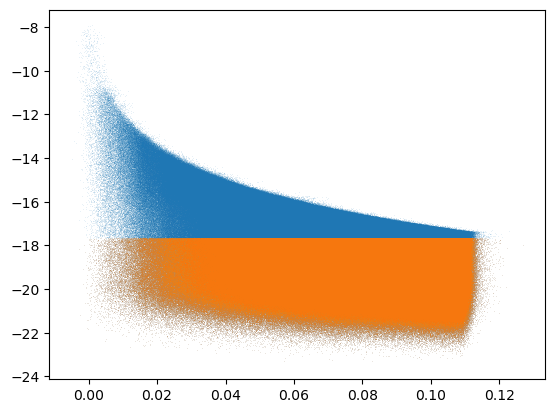

In [49]:
plt.plot(m0_zobs, m0_abs_mag, ',', alpha=0.1)
plt.plot(m0_zobs[mask], m0_abs_mag[mask], ',', alpha=0.1)

In [11]:
d_data = fits.open(CONFIG.data_bgs_clus_data)[1].data
d_rand = fits.open(CONFIG.data_bgs_clus_rand)[1].data
d_data.names, d_rand.names, d_data.size, d_rand.size

(['RA', 'DEC', 'Z', 'WEIGHT', 'NDENS'],
 ['RA', 'DEC', 'Z', 'WEIGHT', 'NDENS'],
 819423,
 16388460)

In [12]:
m_data = fits.open(CONFIG.mock_bgs_clus_data.format(phase=0, real=0))[1].data
m_rand = fits.open(CONFIG.mock_bgs_clus_rand)[1].data
m_data.names, m_rand.names, m_data.size, m_rand.size

(['RA', 'DEC', 'Z', 'WEIGHT', 'NDENS'],
 ['RA', 'DEC', 'Z', 'WEIGHT', 'NDENS'],
 826768,
 21622598)

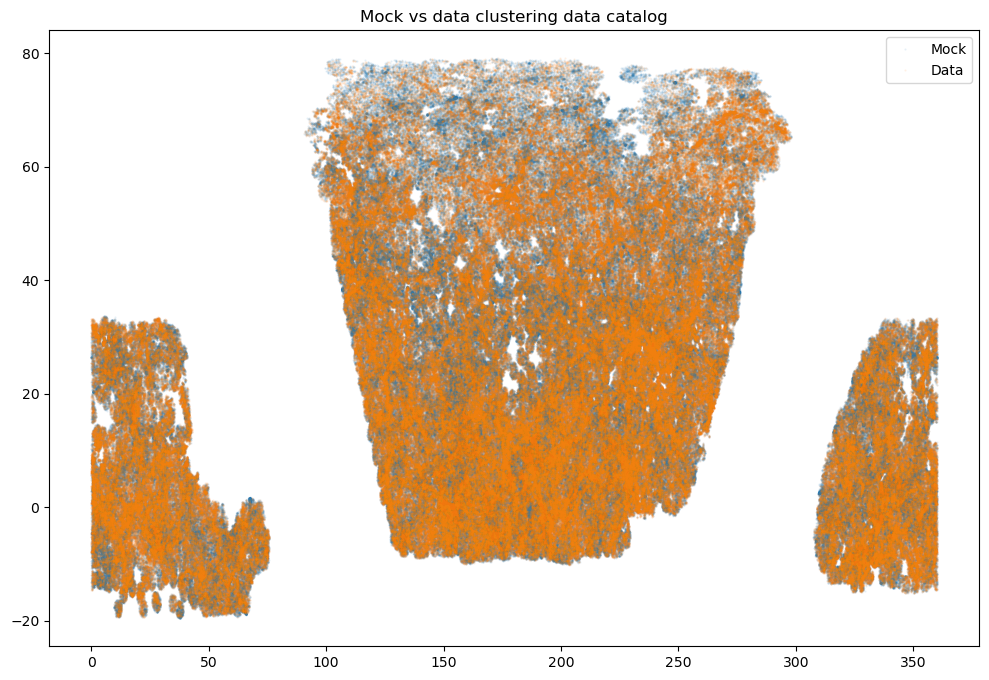

In [13]:
plt.figure(figsize=(12, 8))
plt.plot(m_data['RA'], m_data['DEC'], '.', ms=1, alpha=0.1, label='Mock')
plt.plot(d_data['RA'], d_data['DEC'], '.', ms=1, alpha=0.1, label='Data')
plt.title('Mock vs data clustering data catalog')
plt.legend()

Text(0, 0.5, 'Dec [deg]')

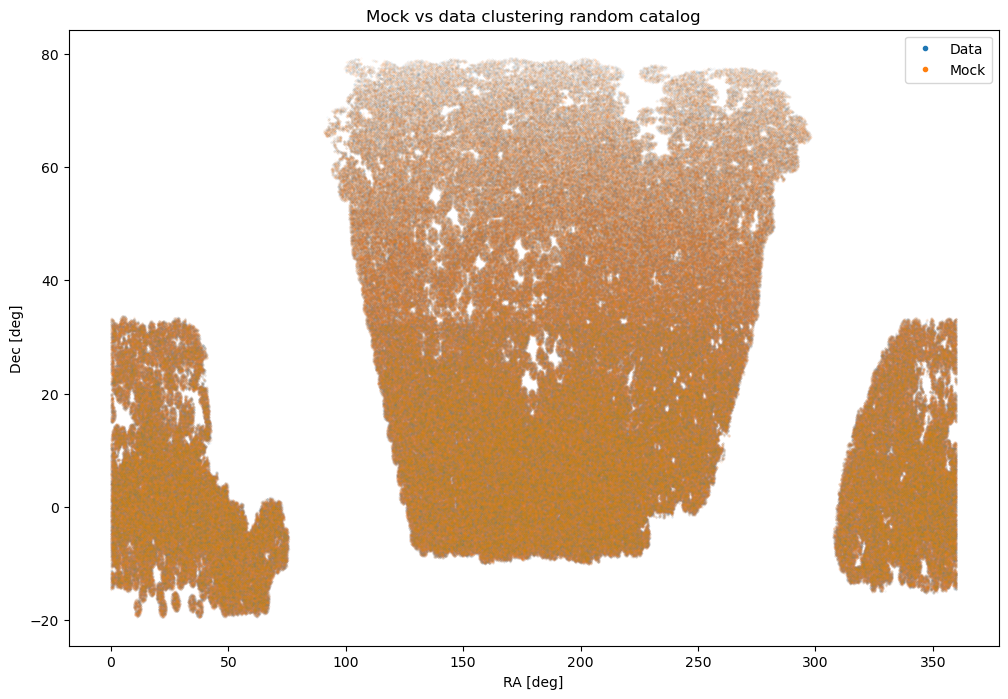

In [15]:
plt.figure(figsize=(12, 8))
plt.plot(d_rand['RA'][::20], d_rand['DEC'][::20], '.', ms=0.5, alpha=0.1)
plt.plot(m_rand['RA'][::20], m_rand['DEC'][::20], '.', ms=0.5, alpha=0.1)
plt.plot([], [], 'C0.', label='Data')
plt.plot([], [], 'C1.', label='Mock')
plt.title('Mock vs data clustering random catalog')
plt.legend()
plt.xlabel('RA [deg]')
plt.ylabel('Dec [deg]') 

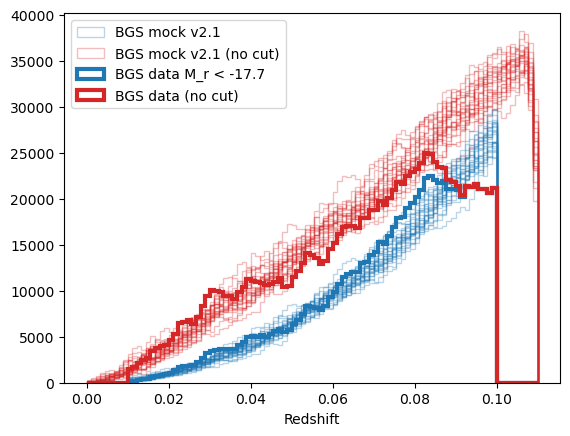

In [20]:
zbins = np.linspace(0, 0.11, 100)

for phase in range(1):
    for real in range(27):
        m0_data_temp = h5py.File(CONFIG.mock_bgs_base_data.format(phase=phase, real=real), 'r')
        m0_comp = m0_data_temp['Y3_COMP'][...]
        mask = np.random.rand(m0_comp.size) < m0_comp
        m0_z = m0_data_temp['zobs'][...][mask] 

        m_data_temp = fits.open(CONFIG.mock_bgs_clus_data.format(phase=phase, real=real))[1].data
        m_z = m_data_temp['Z']
        m_label = 'BGS mock v2.1' if phase == 0 and real ==0 else None 
        m0_label = 'BGS mock v2.1 (no cut)' if phase == 0 and real ==0 else None 
        
        _=plt.hist(m_z, color='C0', bins=zbins, histtype='step', alpha=0.3, label=m_label)
        _=plt.hist(m0_z, color='C3', bins=zbins, histtype='step', alpha=0.3, label=m0_label)

_=plt.hist(d_data['Z'], bins=zbins, histtype='step', color='C0', lw=3, label='BGS data M_r < -17.7')
_=plt.hist(d0_data['Z'], bins=zbins, histtype='step', color='C3', lw=3, label='BGS data (no cut)')

plt.xlabel('Redshift')
plt.legend()
plt.savefig('plots/Nz_bgs_base_clustering_data_vs_mock_v2.1.pdf')

In [66]:
area = 9146 # sq deg
zbins = np.linspace(0, 0.11, 100)
zcen = 0.5*(zbins[:-1]+zbins[1:]) 
zvol = (cosmo.comoving_volume(zbins[1:]).value-cosmo.comoving_volume(zbins[:-1]).value)*(1/(4.*np.pi*((180./np.pi)**2)))

def get_nz(z, weights=None,  area=41253.):
    nz, _ = np.histogram(z, bins=zbins, weights=weights)
    return nz#/zvol/area


In [67]:
m_nzs = []
for phase in range(CONFIG.n_phases):
    for real in range(CONFIG.n_reals):
        m_data_temp = fits.open(CONFIG.mock_bgs_clus_data.format(phase=phase, real=real))[1].data
        m_nz = get_nz(m_data_temp['Z'], area=area)
        #print(phase, real, len(m_data_temp))
        m_nzs.append(m_nz)
m_nzs = np.array(m_nzs) 
print(m_nzs.shape)

(27, 99)


In [65]:
m0_nzs = []
for phase in range(CONFIG.n_phases):
    for real in range(CONFIG.n_reals):
        m0_data_temp = h5py.File(CONFIG.mock_bgs_base_data.format(phase=phase, real=real), 'r')
        m0_app_mag = m0_data_temp['app_mag'][...]
        m0_zobs = m0_data_temp['zobs'][...]
        m0_abs_mag = m0_data_temp['abs_mag'][...]
        m0_comp = m0_data_temp['Y3_COMP'][...]
        m0_data_temp.close()
        
        mask = (
                (m0_app_mag < BGS_CLUS.appmaglim) & 
                #(m0_abs_mag < BGS_CLUS.absmaglim) & 
                (m0_comp < np.random.rand(m0_comp.size)) & 
                (m0_zobs > BGS_CLUS.zmin) & 
                (m0_zobs < BGS_CLUS.zmax)
                )
        print(phase, real, mask.size, np.sum(mask))

        m0_nz = get_nz(m0_zobs[mask], area=area)
        m0_nzs.append(m0_nz)
m0_nzs = np.array(m0_nzs) 


0 0 5429324 2813946
0 1 5330320 2752282
0 2 5328103 2760623
0 3 5325039 2748217
0 4 5416201 2818820
0 5 5304536 2709840
0 6 5402812 2766929
0 7 5452003 2867136
0 8 5292552 2673684
0 9 5328157 2688334
0 10 5378768 2819881
0 11 5323401 2626605
0 12 5365126 2763192
0 13 5394321 2805902
0 14 5413418 2817904
0 15 5378893 2788613
0 16 5271449 2778756
0 17 5388900 2789028
0 18 5342499 2716329
0 19 5398519 2773667
0 20 5410996 2835079
0 21 5371319 2778615
0 22 5396507 2792733
0 23 5218995 2628552
0 24 5300064 2729300
0 25 5353378 2742618
0 26 5298722 2708747


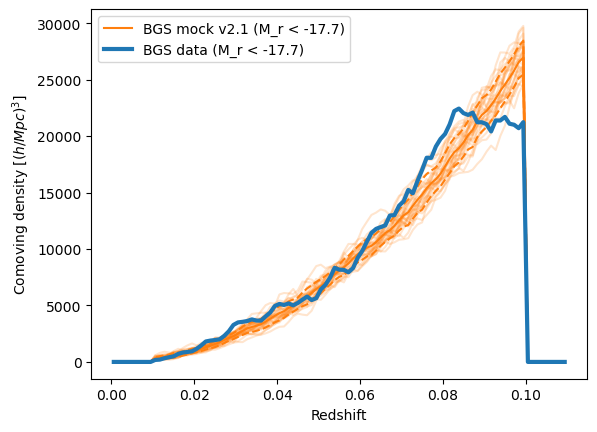

In [68]:
for m_nz in m_nzs:      
    plt.plot(zcen, m_nz, 'C1-', alpha=0.2)
plt.plot(zcen, np.mean(m_nzs, axis=0), 'C1-', label=f"BGS mock {CONFIG.version_clus} (M_r < {BGS_CLUS.absmaglim})") 
plt.plot(zcen, np.mean(m_nzs, axis=0)+np.std(m_nzs, axis=0), 'C1--') 
plt.plot(zcen, np.mean(m_nzs, axis=0)-np.std(m_nzs, axis=0), 'C1--') 

d_nz = get_nz(d_data['Z'], weights=d_data['WEIGHT'], area=area)
#d_nz = get_nz(d_data['Z'], area=area)

plt.plot(zcen, d_nz, 'C0-', lw=3, label='BGS data (M_r < -17.7)')
#plt.plot(d_data['Z'], d_data['NDENS'], 'C0,')

plt.ylabel('Comoving density [${(h/Mpc)}^3$]')
plt.xlabel('Redshift')
plt.legend()
#plt.ylim(0, 0.01)
plt.savefig(f"plots/Nz_bgs_clustering_data_vs_mock_{CONFIG.version_clus}.pdf")

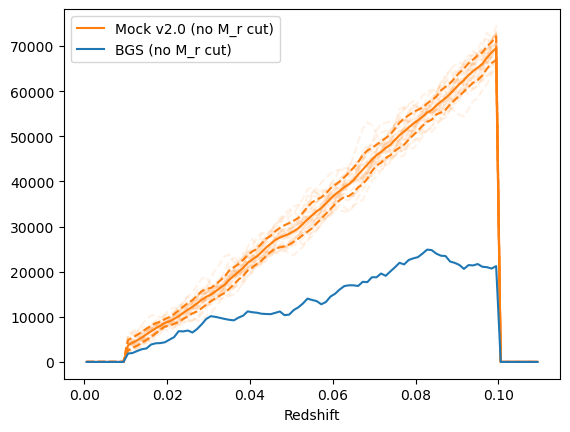

In [69]:

for m0_nz in m0_nzs:      
    plt.plot(zcen, m0_nz, 'C1--', alpha=0.1)
plt.plot(zcen, np.mean(m0_nzs, axis=0), 'C1-', label=f'Mock {CONFIG.version_base} (no M_r cut)') 
plt.plot(zcen, np.mean(m0_nzs, axis=0)+np.std(m0_nzs, axis=0), 'C1--') 
plt.plot(zcen, np.mean(m0_nzs, axis=0)-np.std(m0_nzs, axis=0), 'C1--') 


d0_nz = get_nz(d0_data['Z'], weights=d0_data['WEIGHT'], area=area)
plt.plot(zcen, d0_nz, 'C0-', label='BGS (no M_r cut)')

#plt.ylabel('Comoving density [${(h/Mpc)}^3$]')
plt.xlabel('Redshift')
plt.legend()
plt.savefig(f"plots/Nz_bgs_base_data_vs_mock_{CONFIG.version_base}.pdf")